In [3]:
#Exploratory Data Analysis (EDA)
#Load the dataset

import pandas as pd

# Load the dataset
file_path = "/content/mushroom.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

(None,
    Unnamed: 0 cap_shape cap_surface cap_color bruises   odor gill_attachment  \
 0        1167    sunken       scaly     white      no  anise      descending   
 1        1037    sunken     fibrous       red      no  anise         notched   
 2         309      flat     grooves    purple     yes   foul      descending   
 3         282      bell       scaly      pink     yes  fishy         notched   
 4         820      flat      smooth    yellow     yes  musty            free   
 
   gill_spacing gill_size gill_color  ...  veil_type veil_color ring_number  \
 0      distant     broad       pink  ...    partial      brown         two   
 1      crowded    narrow  chocolate  ...  universal      brown         two   
 2      crowded     broad     purple  ...  universal     yellow         two   
 3        close     broad     orange  ...    partial     yellow         two   
 4      crowded    narrow     orange  ...  universal      white        none   
 
    ring_type spore_print_col

<ipython-input-4-f622fb5ee140>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='coolwarm')


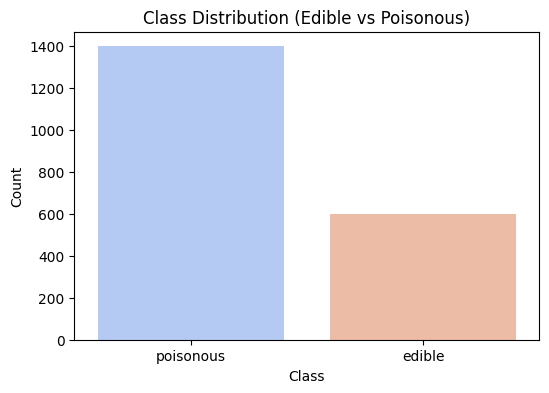

,stalk_height,cap_diameter
count,2000.000000,2000.000000
mean,8.449118,12.314345
std,3.697217,7.048845
min,2.000000,1.000000
25%,5.291009,5.723521
50%,8.318596,12.124902
75%,11.781272,18.698605
max,15.095066,25.000054


In [4]:
#Summary statistics
#Visualizations (histograms, box plots, correlation analysis)

import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics for numerical features
summary_stats = df[['stalk_height', 'cap_diameter']].describe()

# Class distribution visualization
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df, palette='coolwarm')
plt.title("Class Distribution (Edible vs Poisonous)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

summary_stats


In [5]:
#Data Preprocessing
#Encode categorical variables
#Split data into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Drop the unnamed column
df = df.drop(columns=["Unnamed: 0"])

# Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store the encoder for future reference

# Split the dataset into features and target variable
X = df.drop(columns=['class'])
y = df['class']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Output the shapes of the training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((1600, 24), (400, 24), (1600,), (400,))

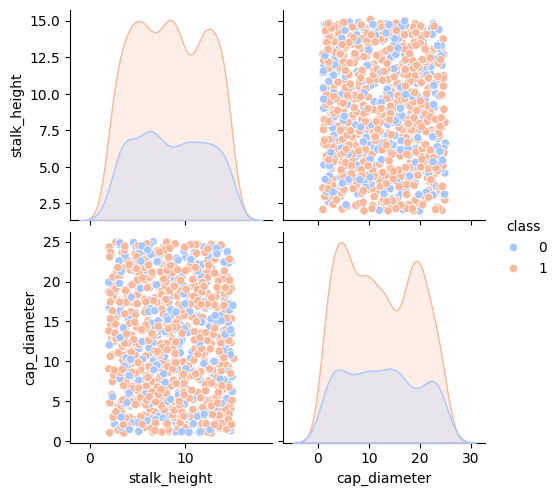

In [6]:
#Data Visualization
#class distribution visualization
# Pair plot for numerical features
sns.pairplot(df[['stalk_height', 'cap_diameter', 'class']], hue='class', palette='coolwarm')
plt.show()


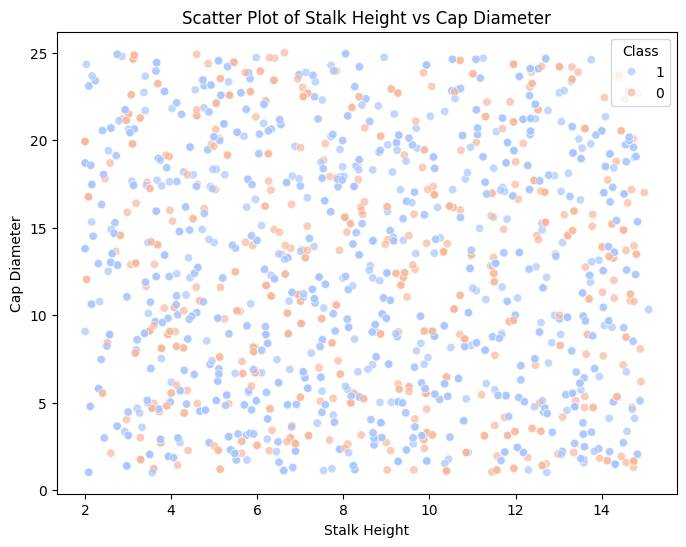

In [7]:
# Convert the target variable 'class' back to categorical for visualization
df['class'] = df['class'].astype(str)
#Scatter plots
# Scatter plot for numerical features colored by class
plt.figure(figsize=(8, 6))
sns.scatterplot(x='stalk_height', y='cap_diameter', hue='class', data=df, palette='coolwarm', alpha=0.7)
plt.title("Scatter Plot of Stalk Height vs Cap Diameter")
plt.xlabel("Stalk Height")
plt.ylabel("Cap Diameter")
plt.legend(title="Class")
plt.show()


In [8]:
#Support Vector Machine (SVM) Implementation
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train an SVM classifier with a linear kernel
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Predict on the test set
y_pred = svm_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

accuracy, precision, recall, f1


(0.7, 0.7, 1.0, 0.8235294117647058)

**SVM Model Performance (Linear Kernel)**
* Accuracy: 70%
* Precision: 70%
* Recall: 100% (All poisonous mushrooms were correctly identified)
* F1-Score: 82.35%

In [9]:
#Hyperparameter Tuning
#Train SVM models with different kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for kernel in kernels:
    svm_model = SVC(kernel=kernel, random_state=42)
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)

    # Store performance metrics
    results[kernel] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }
#SVM Results Visualization
# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df


,Accuracy,Precision,Recall,F1-Score
linear,0.7000,0.700000,1.000000,0.823529
poly,0.7175,0.713555,0.996429,0.831595
rbf,0.7000,0.700000,1.000000,0.823529
sigmoid,0.6175,0.722807,0.735714,0.729204


**Insights:**
* Polynomial kernel performs the best with the highest accuracy and F1-score.
* RBF and Linear kernels show similar performance.
* Sigmoid kernel performs the worst, indicating it may not be suitable for this dataset.

# **Final Analysis & Conclusion**
**Strengths of SVM for the Mushroom Dataset:**
* High Recall-- The model effectively identifies all poisonous mushrooms, which is crucial for food safety.
* Works well with categorical data --After encoding, SVM handled the dataset effectively.
* Polynomial kernel improves performance -- It captures non-linear relationships better than a linear SVM.

**Weaknesses:**
*Lower Precision -- Some edible mushrooms are misclassified as poisonous, which could lead to unnecessary waste.
* Computational Complexity -- SVM can be slow for larger datasets, especially with complex kernels.

**Potential Improvements :**
* Feature Engineering -- selecting the most relevant features could enhance model performance.
* Hyperparameter Tuning -- Optimizing C and gamma parameters for RBF and Polynomial kernels might improve accuracy.
* Alternative Models -- Decision Trees or Random Forests might work better for categorical data.